In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.shape

(1000, 3)

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
224,7.15,19.0,0
401,6.74,22.0,0
522,6.71,63.0,1
202,6.51,48.0,1
140,6.85,22.0,1


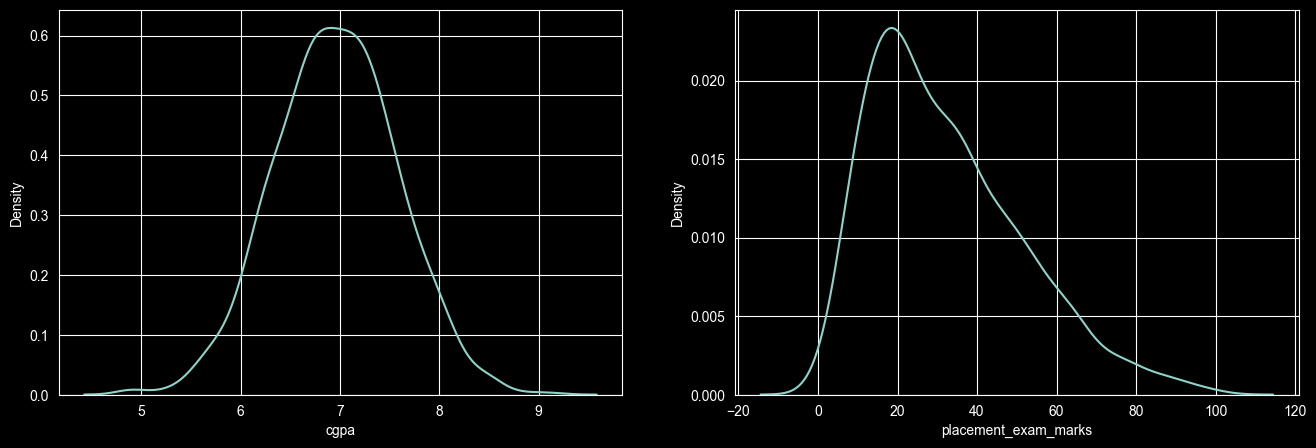

In [6]:
plt.figure(figsize=(16, 5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])
plt.show()

In [7]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [8]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [9]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

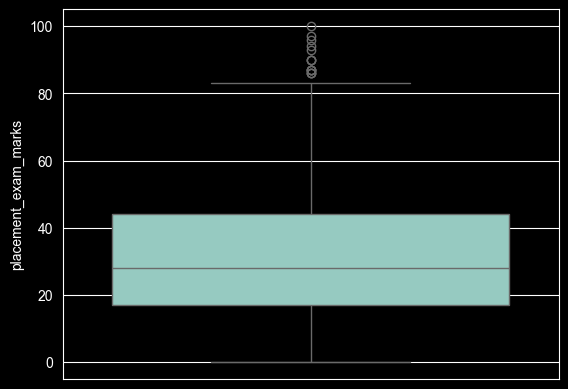

In [10]:
sns.boxplot(df['placement_exam_marks'])

In [11]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [12]:
percentile75

np.float64(44.0)

In [13]:
percentile25

np.float64(17.0)

In [14]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [15]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [16]:
print("upper_limit: ", upper_limit)
print("lower_limit: ", lower_limit)

upper_limit:  84.5
lower_limit:  -23.5


Finding Outliers

In [17]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [18]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [19]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [20]:
new_df.shape

(985, 3)

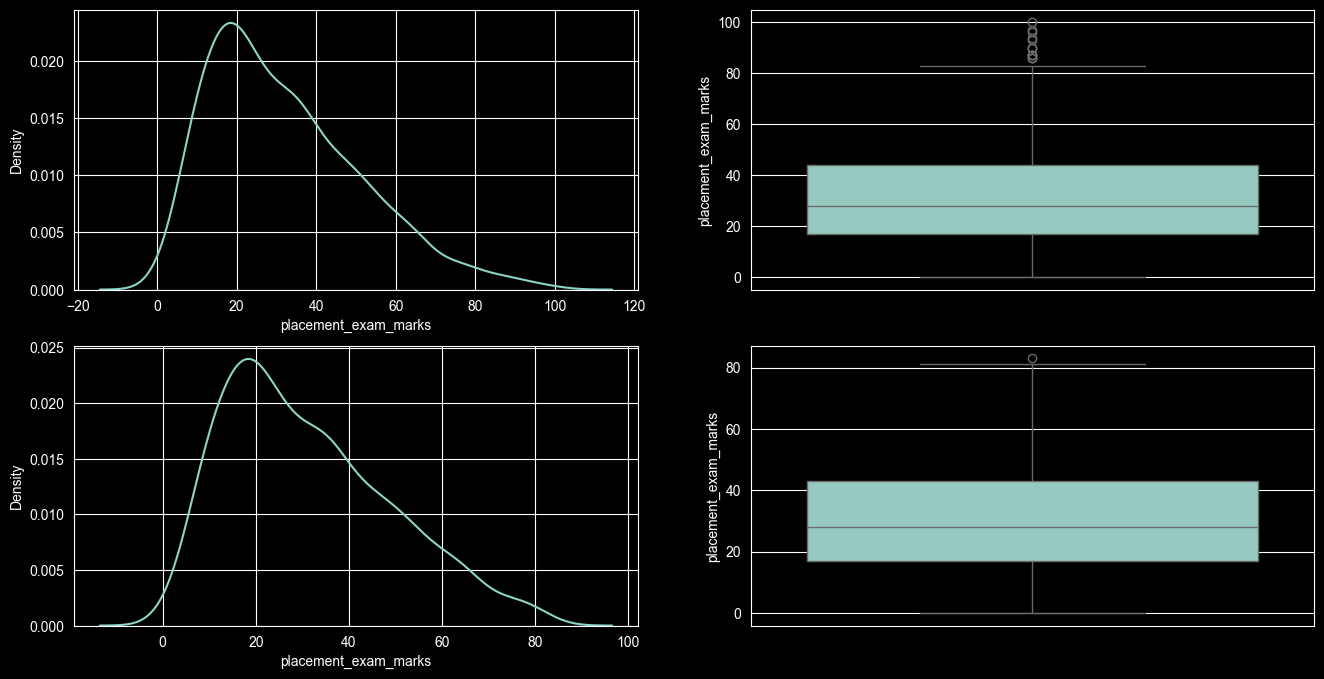

In [21]:
# comparing

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.kdeplot(df['placement_exam_marks'])
plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2, 2, 3)
sns.kdeplot(new_df['placement_exam_marks'])
plt.subplot(2, 2, 4)
sns.boxplot(new_df['placement_exam_marks'])
plt.show()

Capping


In [22]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [23]:
new_df_cap.shape

(1000, 3)

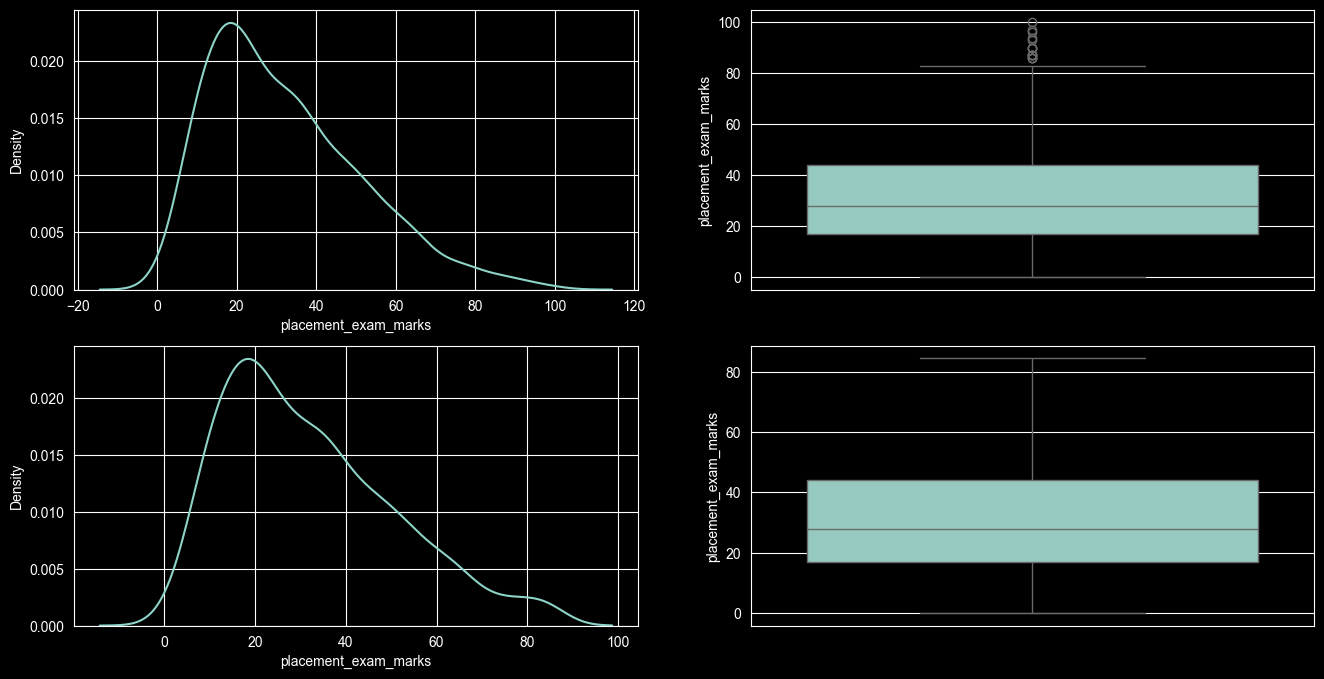

In [24]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.kdeplot(df['placement_exam_marks'])
plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2, 2, 3)
sns.kdeplot(new_df_cap['placement_exam_marks'])
plt.subplot(2, 2, 4)
sns.boxplot(new_df_cap['placement_exam_marks'])
plt.show()